Visualizing: BA2_96_1_D10_split2
Timepoints: 11 days
Days: [3.0, 6.0, 8.0, 10.0, 13.0, 15.0, 17.0, 20.5, 24.0, 28.0, 30.0]
Loaded 11 masks


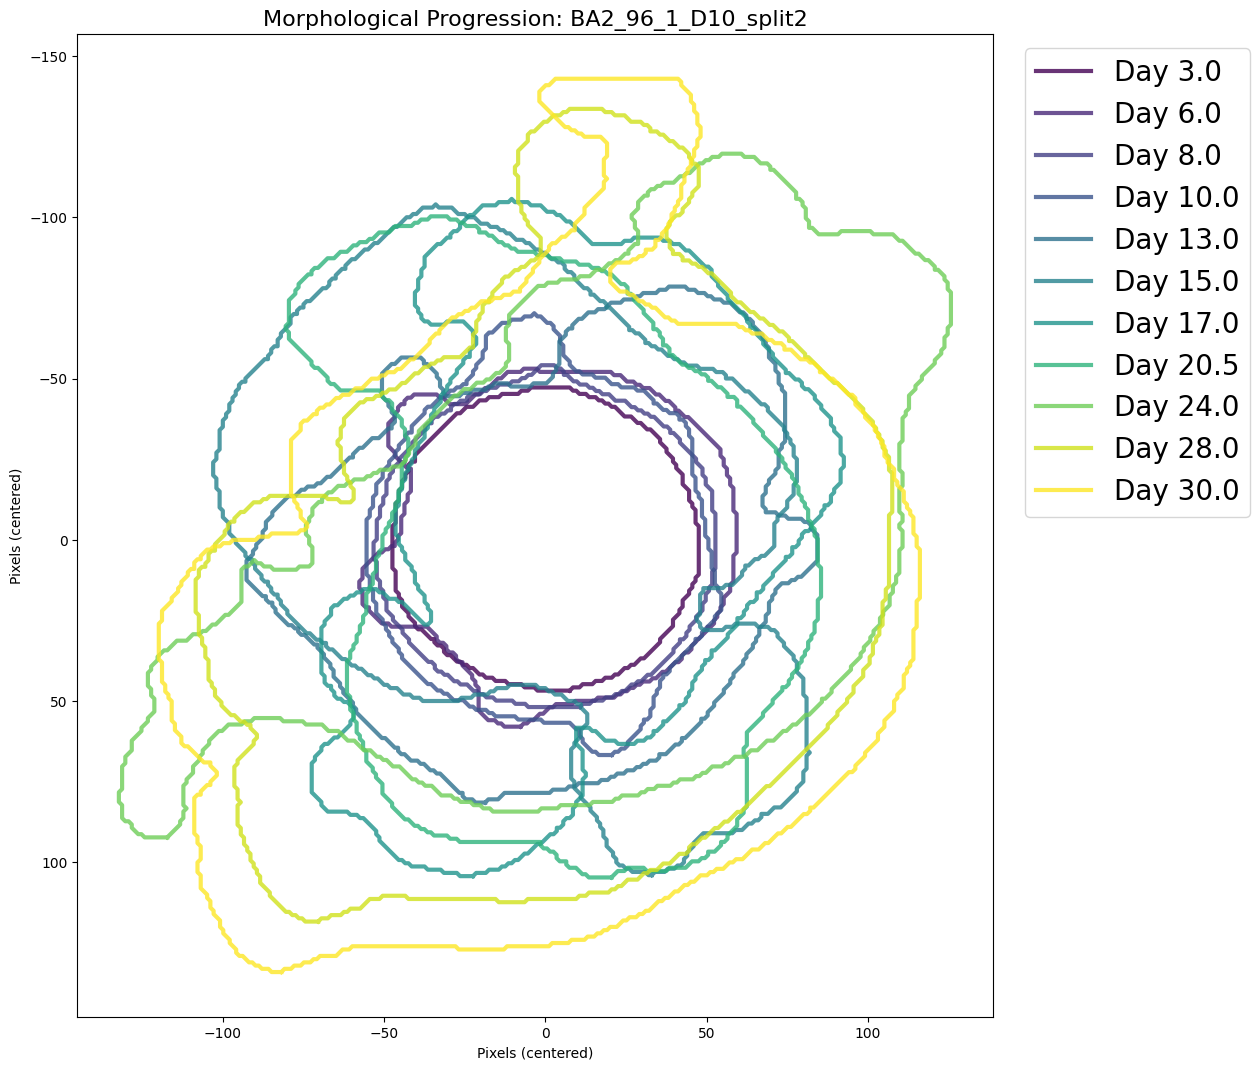

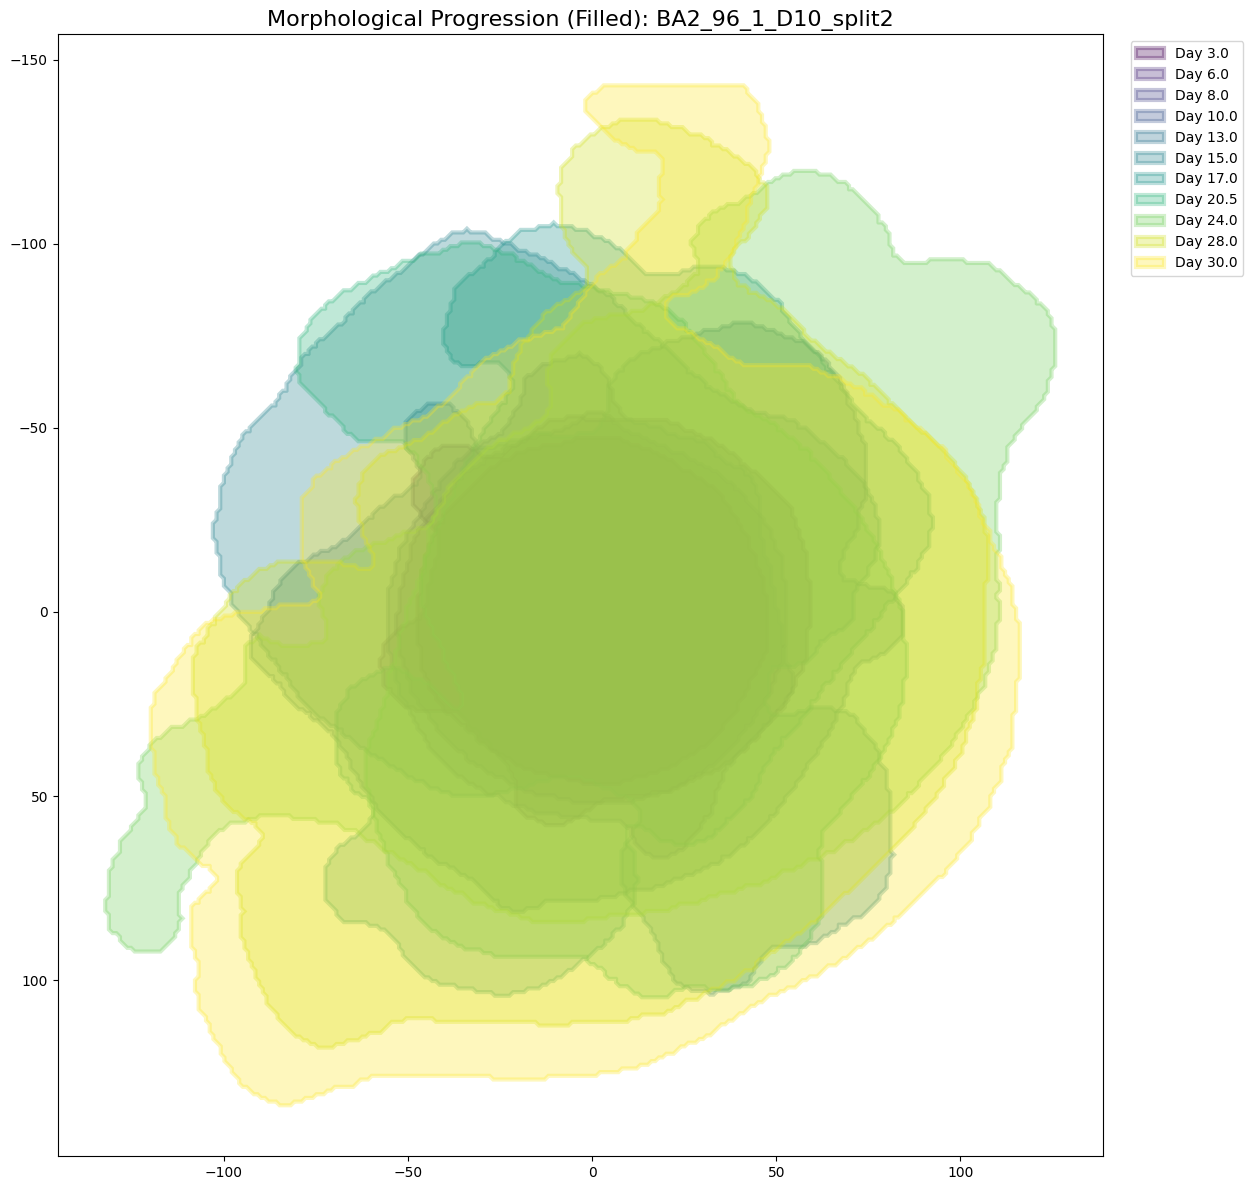

In [3]:
# notebooks/visualize_organoid_morphology_progression.ipynb

import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
from skimage.io import imread
from skimage.measure import find_contours
from pathlib import Path
# Create rainbow colors (HSV -> RGB)
import matplotlib as mpl
import sys, os, json


# --- Add repo root so `from config import ALL_DATA_JSON` works ---
def add_repo_root(markers=("config.py", ".env")):
    here = Path.cwd()
    for p in [here, *here.parents]:
        if all((p / m).exists() for m in markers):
            sys.path.insert(0, str(p))
            return p
    raise RuntimeError("Could not find repo root with config.py and .env")

repo_root = add_repo_root()

from config import ALL_DATA_JSON, OUTPUT_FOLDER  # now this should import


def load_json(p):
    with open(p) as f:
        return json.load(f)

# Load series metadata
series_metadata = load_json(OUTPUT_FOLDER / 'complete_series_metadata_no_blanks.json')
data = load_json(OUTPUT_FOLDER / 'complete_series_data_no_blanks.json')

# Pick an organoid to visualize
organoid_id = list(series_metadata.keys())[100]  # First one
print(f"Visualizing: {organoid_id}")

series = series_metadata[organoid_id]
print(f"Timepoints: {len(series['days'])} days")
print(f"Days: {series['days']}")

# Load all masks for this series
masks = []
days = []
for entry_key in series['entry_keys']:
    entry = data[entry_key]
    if 'lstm_processed' in entry and entry['lstm_processed']['mask_path']:
        mask_path = entry['lstm_processed']['mask_path']
        mask = imread(mask_path)
        masks.append(mask)
        days.append(entry['mdl_day'])
        
print(f"Loaded {len(masks)} masks")

# Function to get contour and centroid
def get_contour_and_centroid(mask):
    """Extract outer contour and calculate centroid"""
    # Find contours (level=0.5 for binary mask)
    contours = find_contours(mask, level=0.5)
    
    if not contours:
        return None, None
    
    # Get largest contour (outer boundary)
    contour = max(contours, key=len)
    
    # Calculate centroid
    centroid = contour.mean(axis=0)
    
    return contour, centroid

# Extract and center all contours
centered_contours = []
for mask in masks:
    contour, centroid = get_contour_and_centroid(mask)
    if contour is not None:
        # Center the contour by subtracting centroid
        centered = contour - centroid
        centered_contours.append(centered)
    else:
        centered_contours.append(None)



n_timepoints = len(centered_contours)
cmap = plt.get_cmap("viridis")
# use actual day values if available, else index-based
vals = np.array(days) if len(days) == n_timepoints else np.arange(n_timepoints)

norm = mpl.colors.Normalize(vmin=float(np.min(vals)), vmax=float(np.max(vals)))
colors = [cmap(norm(v)) for v in vals]


# Plot all contours overlaid
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

for i, (contour, day) in enumerate(zip(centered_contours, days)):
    if contour is not None:
        # Plot contour (swap x,y for correct orientation)
        ax.plot(contour[:, 1], contour[:, 0], 
               color=colors[i], linewidth=3, 
               label=f'Day {day:.1f}', alpha=0.8)

ax.set_aspect('equal')
ax.invert_yaxis()  # Match image coordinates
ax.set_title(f'Morphological Progression: {organoid_id}', fontsize=16)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=20)
ax.grid(False)
ax.set_xlabel('Pixels (centered)')
ax.set_ylabel('Pixels (centered)')

plt.tight_layout()
plt.show()

# Also create a version with filled contours for "heat map" effect
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

for i, (contour, day) in enumerate(zip(centered_contours, days)):
    if contour is not None:
        ax.fill(contour[:, 1], contour[:, 0], 
               color=colors[i], alpha=0.3, edgecolor=colors[i], 
               linewidth=3, label=f'Day {day:.1f}')

ax.set_aspect('equal')
ax.invert_yaxis()
ax.set_title(f'Morphological Progression (Filled): {organoid_id}', fontsize=16)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
ax.grid(False)

plt.tight_layout()
plt.show()

In [ ]:
import json
from collections import Counter
from config import OUTPUT_FOLDER

# Load data
data = json.load(open(OUTPUT_FOLDER / 'complete_series_data_no_blanks.json'))
series_metadata = json.load(open(OUTPUT_FOLDER / 'complete_series_metadata_no_blanks.json'))

def get_label_from_survey(entry):
    """
    Extract binary label from survey data using majority vote
    Returns: 1 (Acceptable/Good), 0 (Not Acceptable/Bad), or None (no data)
    """
    if 'survey' not in entry or not entry['survey']:
        return None
    
    survey = entry['survey']
    
    if 'evaluations' not in survey or not survey['evaluations']:
        return None
    
    # Count votes from all evaluators
    votes = [ev.get('evaluation') for ev in survey['evaluations']]
    
    acceptable_count = votes.count('Acceptable')
    not_acceptable_count = votes.count('Not Acceptable')
    
    # Majority vote
    if acceptable_count > not_acceptable_count:
        return 1  # Good
    elif not_acceptable_count > acceptable_count:
        return 0  # Bad
    else:
        # Tie - skip this organoid
        return None

# Check labels for complete series
organoid_labels = {}

for organoid_id in series_metadata.keys():
    # Get the final timepoint (Day 30) for this organoid
    entry_keys = series_metadata[organoid_id]['entry_keys']
    final_entry = data[entry_keys[-1]]  # Last day
    
    label = get_label_from_survey(final_entry)
    if label is not None:
        organoid_labels[organoid_id] = label

# Analysis
print(f"Total complete series: {len(series_metadata)}")
print(f"Series with labels: {len(organoid_labels)}")
print(f"Percentage with labels: {100*len(organoid_labels)/len(series_metadata):.1f}%\n")

label_counts = Counter(organoid_labels.values())
print(f"Class distribution:")
print(f"  Good (Acceptable): {label_counts[1]}")
print(f"  Bad (Not Acceptable): {label_counts[0]}")
print(f"  Balance: {100*label_counts[1]/(label_counts[0]+label_counts[1]):.1f}% good\n")

# Show some examples
print("Examples:")
for i, (org_id, label) in enumerate(list(organoid_labels.items())[:5]):
    print(f"  {org_id}: {'Good' if label == 1 else 'Bad'}")

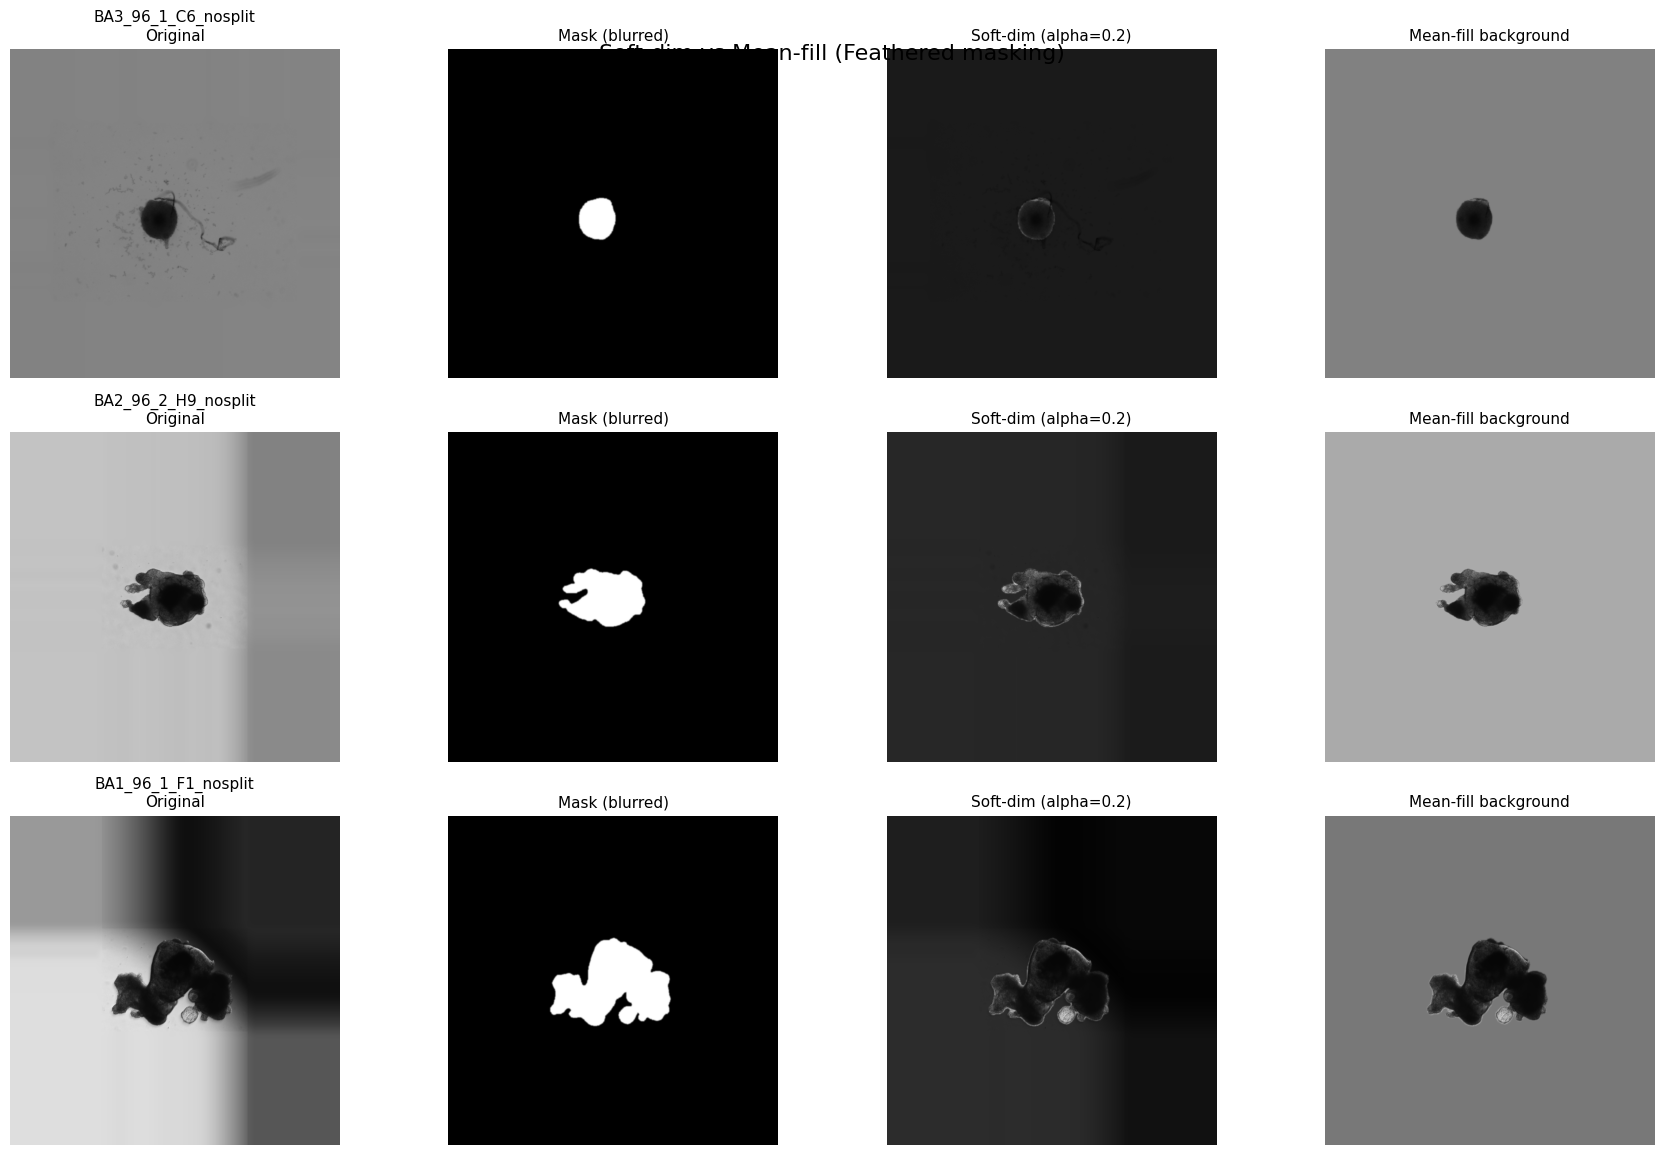

Tip: if Soft-dim looks too dark, lower alpha->0.3 or use Mean-fill.
You can also try blur_kernel=(9,9) for smoother edges.


In [13]:
# ==== Feathered vs Mean-fill visualization ====
import numpy as np, cv2, random
import matplotlib.pyplot as plt
from skimage.io import imread
from pathlib import Path

alpha = 0.2          # background retention for soft-dim
blur_kernel = (5, 5) # None to disable blur

def to_rgb(img):
    return np.stack([img]*3, axis=-1) if img.ndim == 2 else img

def read_mask(mask_path, fallback_shape):
    if mask_path and Path(mask_path).exists():
        m = imread(mask_path)
        if m.ndim == 3:
            m = m[:, :, 0]
        m = m.astype(np.float32) / 255.0
        if blur_kernel is not None:
            m = cv2.GaussianBlur(m, blur_kernel, 0)
        return m
    return np.zeros(fallback_shape[:2], dtype=np.float32)

def soft_dim(img, mask, alpha=0.2):
    # img float [0..255], mask float [0..1]
    return img * (alpha + (1.0 - alpha) * mask[:, :, None])

def mean_fill(img, mask):
    mean_rgb = img.reshape(-1, 3).mean(axis=0)[None, None, :]
    return img * mask[:, :, None] + mean_rgb * (1.0 - mask[:, :, None])

# pick 3 random organoids
all_organoid_ids = list(series_metadata.keys())
random_organoids = random.sample(all_organoid_ids, 3)

fig, axes = plt.subplots(len(random_organoids), 4, figsize=(18, 12))
fig.suptitle("Soft-dim vs Mean-fill (Feathered masking)", fontsize=16, y=0.93)

for r, organoid_id in enumerate(random_organoids):
    entry_keys = series_metadata[organoid_id]['entry_keys']
    ek = entry_keys[random.randint(0, len(entry_keys)-1)]
    entry = data[ek]

    img_path  = entry['lstm_processed']['image_path']
    mask_path = entry['lstm_processed']['mask_path']

    img = to_rgb(imread(img_path)).astype(np.float32)      # [H,W,3], 0..255
    mask = read_mask(mask_path, img)

    # process
    img_soft = np.clip(soft_dim(img.copy(), mask, alpha) / 255.0, 0, 1)
    img_mean = np.clip(mean_fill(img.copy(), mask) / 255.0, 0, 1)

    # plot
    ax0, ax1, ax2, ax3 = axes[r]
    ax0.imshow(np.clip(img/255.0, 0, 1))
    ax0.set_title(f"{organoid_id}\nOriginal", fontsize=11)
    ax0.axis('off')

    ax1.imshow(mask, cmap='gray', vmin=0, vmax=1)
    ax1.set_title("Mask (blurred)" if blur_kernel else "Mask", fontsize=11)
    ax1.axis('off')

    ax2.imshow(img_soft)
    ax2.set_title(f"Soft-dim (alpha={alpha})", fontsize=11)
    ax2.axis('off')

    ax3.imshow(img_mean)
    ax3.set_title("Mean-fill background", fontsize=11)
    ax3.axis('off')

plt.tight_layout()
plt.show()

print("Tip: if Soft-dim looks too dark, lower alpha->0.3 or use Mean-fill.\n"
      "You can also try blur_kernel=(9,9) for smoother edges.")


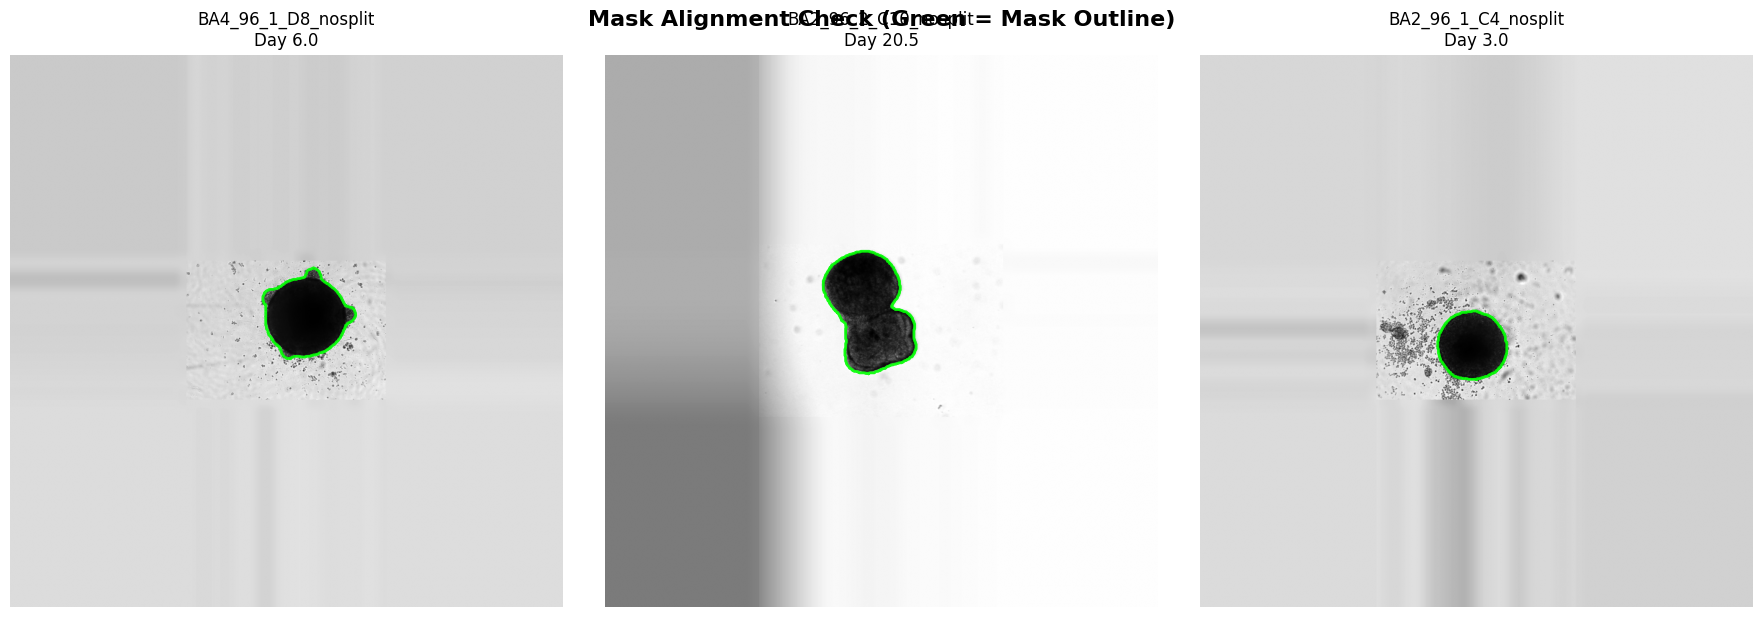

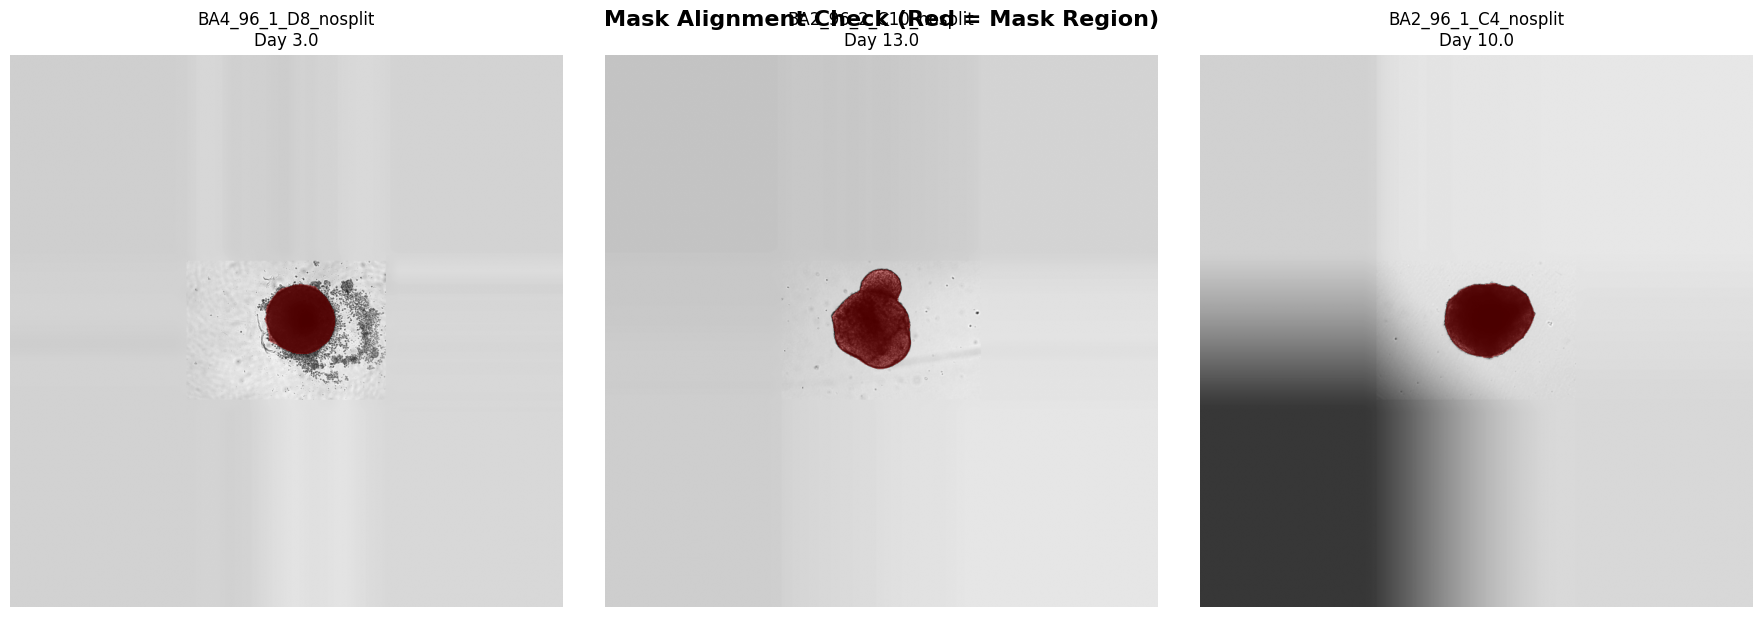


Check if:
1. Green outlines follow organoid edges closely
2. Red overlay covers the organoid region accurately
3. Masks don't extend into padding/background areas

If masks are misaligned, that's why adding them hurt performance!

Run this cell multiple times to see different random samples!


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.measure import find_contours
from pathlib import Path
import sys
import json
import random

# --- Add repo root ---
def add_repo_root(markers=("config.py", ".env")):
    here = Path.cwd()
    for p in [here, *here.parents]:
        if all((p / m).exists() for m in markers):
            sys.path.insert(0, str(p))
            return p
    raise RuntimeError("Could not find repo root with config.py and .env")

repo_root = add_repo_root()
from config import OUTPUT_FOLDER

def load_json(p):
    with open(p) as f:
        return json.load(f)

# Load data
series_metadata = load_json(OUTPUT_FOLDER / 'complete_series_metadata_no_blanks.json')
data = load_json(OUTPUT_FOLDER / 'complete_series_data_no_blanks.json')

# Pick 3 random organoids
all_organoid_ids = list(series_metadata.keys())
random_organoids = random.sample(all_organoid_ids, 3)

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, organoid_id in enumerate(random_organoids):
    ax = axes[idx]
    
    # Get entry keys for this organoid
    entry_keys = series_metadata[organoid_id]['entry_keys']
    
    # Pick a RANDOM day from this organoid's timepoints
    random_idx = random.randint(0, len(entry_keys) - 1)
    entry_key = entry_keys[random_idx]
    entry = data[entry_key]
    
    # Get day
    day = entry['mdl_day']
    
    # Load image and mask from lstm_processed
    img_path = entry['lstm_processed']['image_path']
    mask_path = entry['lstm_processed']['mask_path']
    
    # Load image
    img = imread(img_path)
    
    # Load mask
    if mask_path and Path(mask_path).exists():
        mask = imread(mask_path)
    else:
        mask = np.zeros_like(img[:, :, 0])
    
    # Display image
    ax.imshow(img, cmap='gray' if len(img.shape) == 2 else None)
    
    # Find and plot mask contours in GREEN
    contours = find_contours(mask, level=0.5)
    
    for contour in contours:
        ax.plot(contour[:, 1], contour[:, 0], 
                color='lime', linewidth=2, alpha=0.9)
    
    ax.set_title(f'{organoid_id}\nDay {day:.1f}', fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.suptitle('Mask Alignment Check (Green = Mask Outline)', 
             fontsize=16, y=1.02, fontweight='bold')
plt.show()

# Also create a version with mask overlay in red semi-transparent
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, organoid_id in enumerate(random_organoids):
    ax = axes[idx]
    
    # Get entry keys for this organoid
    entry_keys = series_metadata[organoid_id]['entry_keys']
    
    # Pick ANOTHER random day
    random_idx = random.randint(0, len(entry_keys) - 1)
    entry_key = entry_keys[random_idx]
    entry = data[entry_key]
    
    # Get day
    day = entry['mdl_day']
    
    # Load image and mask
    img_path = entry['lstm_processed']['image_path']
    mask_path = entry['lstm_processed']['mask_path']
    
    img = imread(img_path)
    
    if mask_path and Path(mask_path).exists():
        mask = imread(mask_path)
    else:
        mask = np.zeros_like(img[:, :, 0])
    
    # Display image
    ax.imshow(img, cmap='gray' if len(img.shape) == 2 else None)
    
    # Overlay mask in red semi-transparent
    mask_rgba = np.zeros((*mask.shape, 4))
    mask_rgba[mask > 0] = [1, 0, 0, 0.3]  # Red with 30% opacity
    ax.imshow(mask_rgba)
    
    ax.set_title(f'{organoid_id}\nDay {day:.1f}', fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.suptitle('Mask Alignment Check (Red = Mask Region)', 
             fontsize=16, y=1.02, fontweight='bold')
plt.show()

print("\nCheck if:")
print("1. Green outlines follow organoid edges closely")
print("2. Red overlay covers the organoid region accurately")
print("3. Masks don't extend into padding/background areas")
print("\nIf masks are misaligned, that's why adding them hurt performance!")
print("\nRun this cell multiple times to see different random samples!")

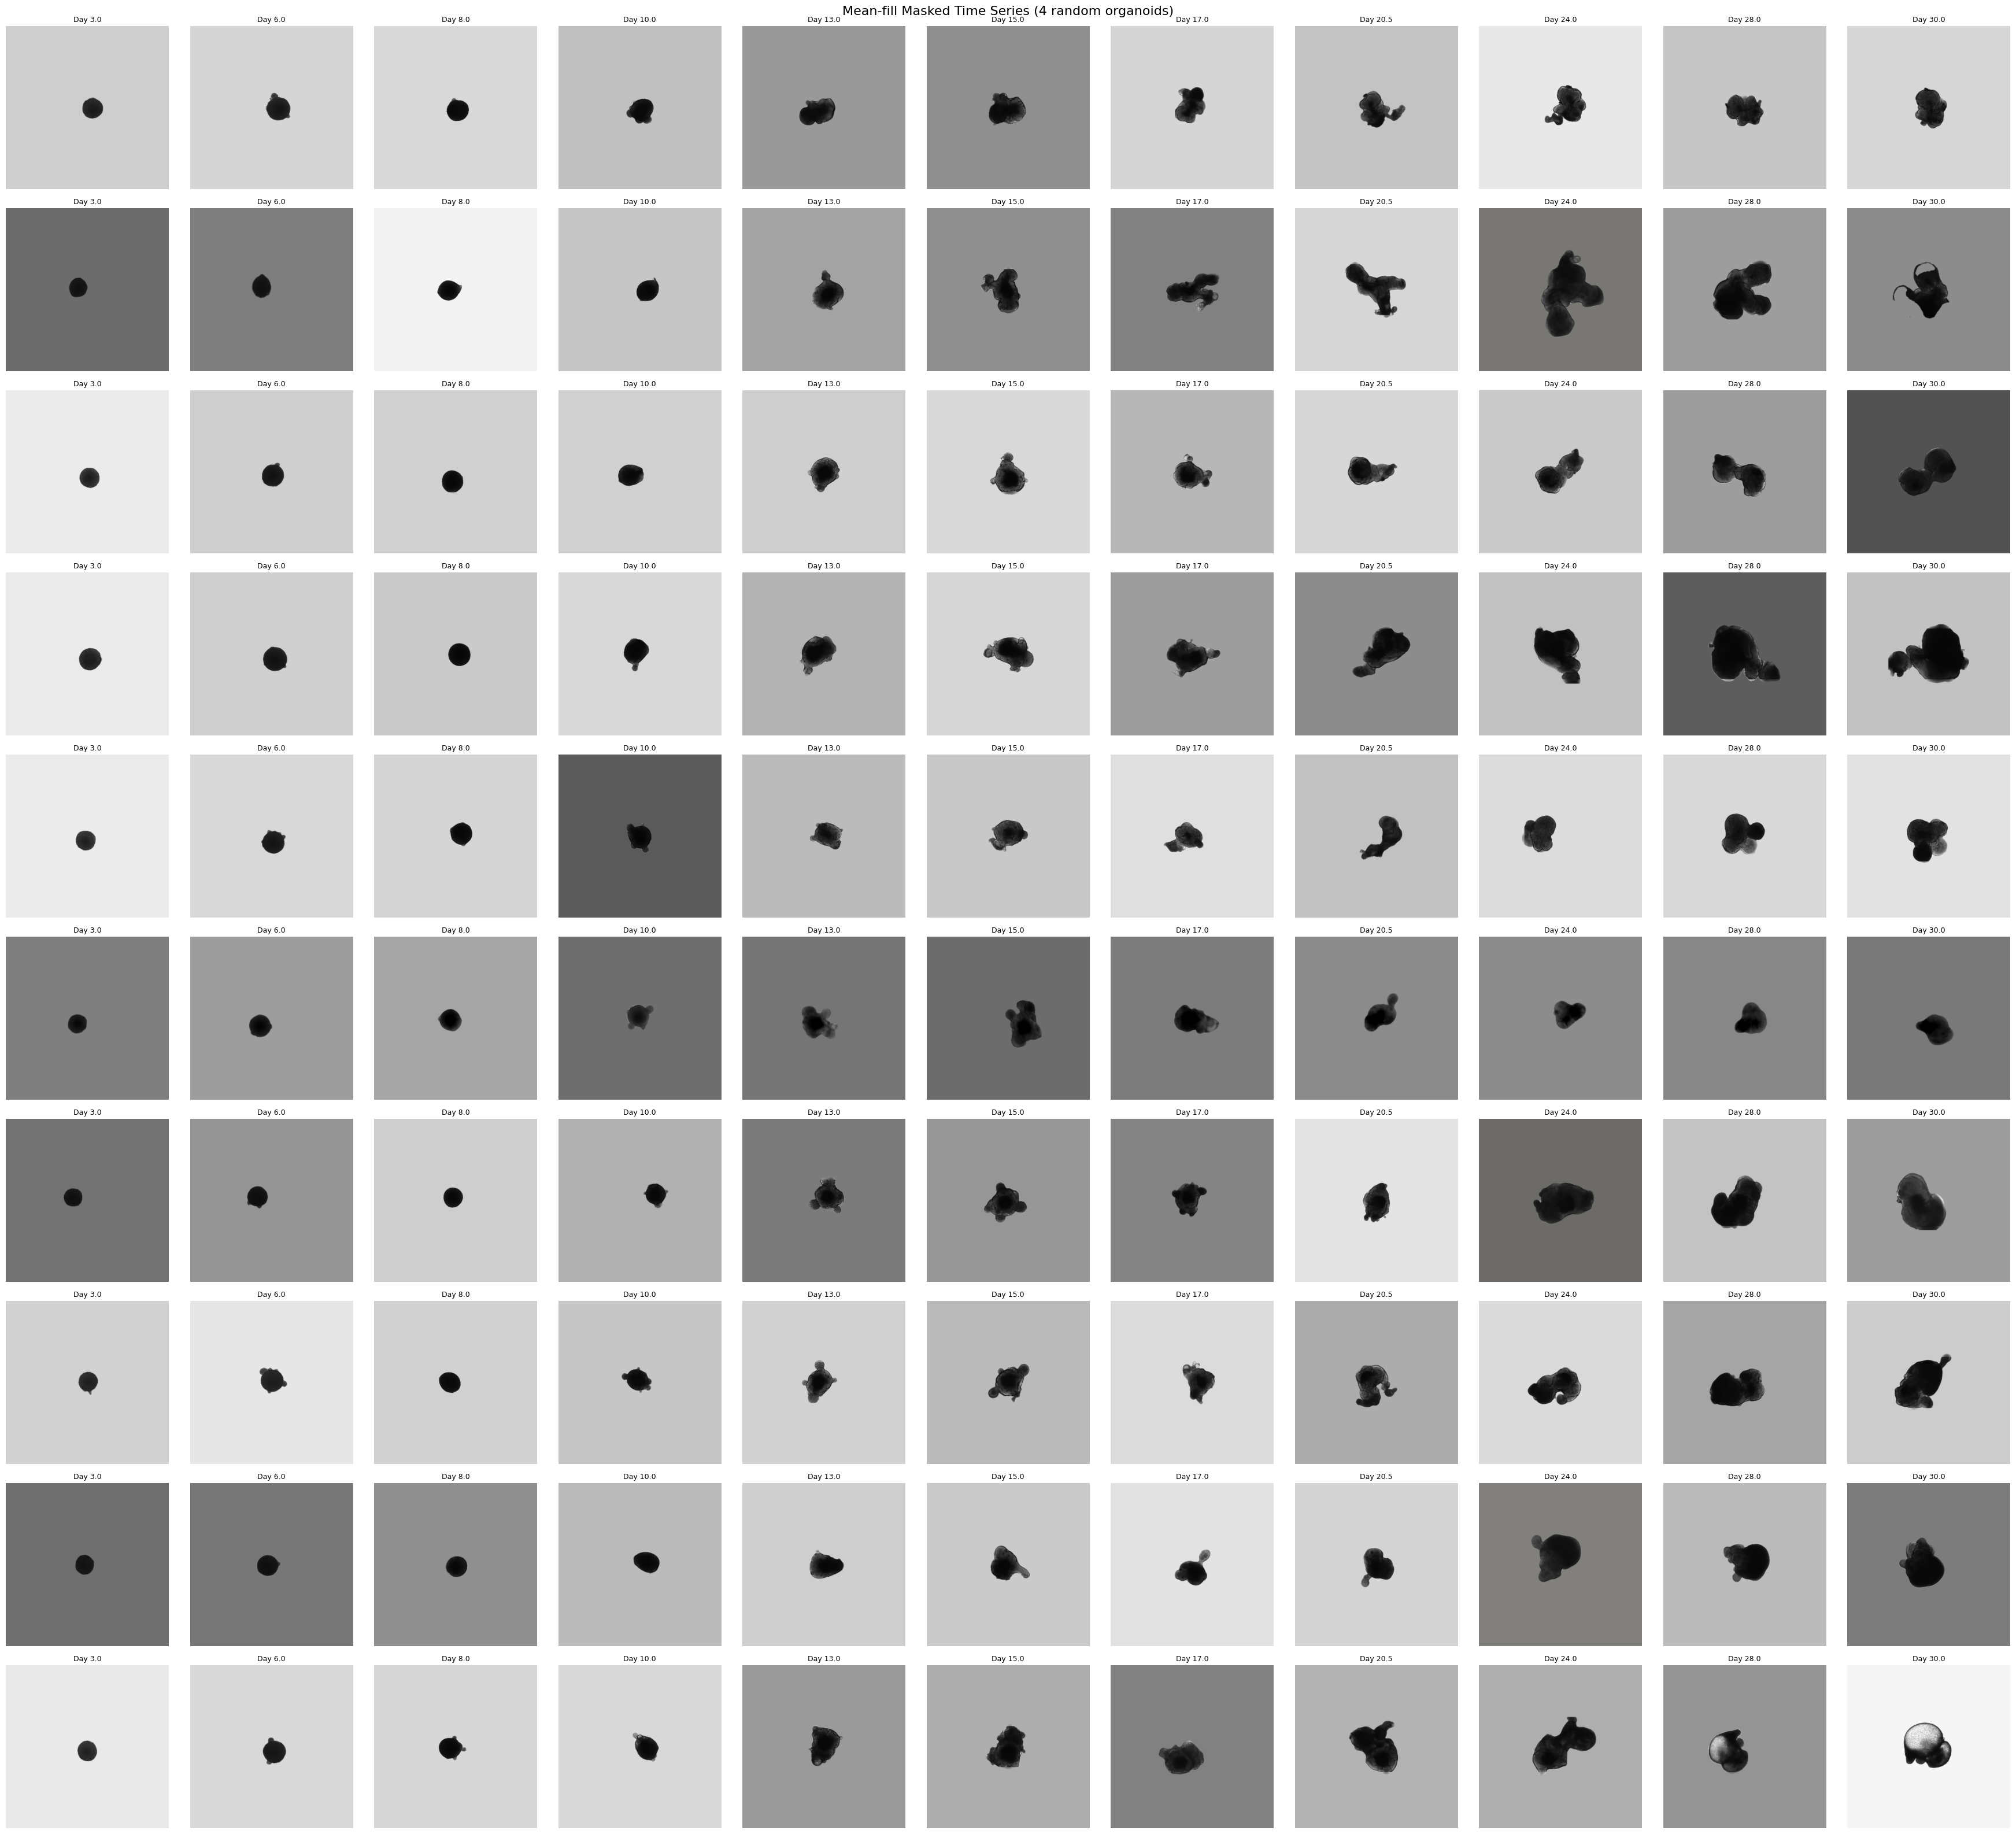

: 

In [ ]:
# ==== Time-series montages of mean-fill masked images (4 random organoids) ====
import numpy as np, cv2, random, json, sys
import matplotlib.pyplot as plt
from pathlib import Path
from skimage.io import imread

# --- repo root + config ---
def add_repo_root(markers=("config.py", ".env")):
    here = Path.cwd()
    for p in [here, *here.parents]:
        if all((p / m).exists() for m in markers):
            sys.path.insert(0, str(p))
            return p
    raise RuntimeError("Could not find repo root with config.py and .env")

repo_root = add_repo_root()
from config import OUTPUT_FOLDER

# ---- params ----
BLUR_KERNEL = (5, 5)   # None to disable
RAND_N = 10             # number of organoids to montage

# ---- utils ----
def load_json(p):
    with open(p) as f:
        return json.load(f)

def to_rgb(img):
    return np.stack([img]*3, axis=-1) if img.ndim == 2 else img

def read_mask(mask_path, shape_hw):
    if mask_path and Path(mask_path).exists():
        m = imread(mask_path)
        if m.ndim == 3:
            m = m[:, :, 0]
        m = m.astype(np.float32) / 255.0
        if BLUR_KERNEL is not None:
            m = cv2.GaussianBlur(m, BLUR_KERNEL, 0)
        # resize if needed
        if m.shape != shape_hw:
            m = cv2.resize(m, (shape_hw[1], shape_hw[0]), interpolation=cv2.INTER_NEAREST)
        return m
    return np.zeros(shape_hw, dtype=np.float32)

def mean_fill(img, mask):
    # img float32 [0..255], mask float [0..1]
    mean_rgb = img.reshape(-1, 3).mean(axis=0)[None, None, :]
    out = img * mask[:, :, None] + mean_rgb * (1.0 - mask[:, :, None])
    return np.clip(out / 255.0, 0, 1)  # -> [0,1] for plotting

# ---- load metadata ----
series_metadata = load_json(OUTPUT_FOLDER / 'complete_series_metadata_no_blanks.json')
data            = load_json(OUTPUT_FOLDER / 'complete_series_data_no_blanks.json')

all_ids = list(series_metadata.keys())
random_ids = random.sample(all_ids, k=min(RAND_N, len(all_ids)))

# ---- build montages ----
# compute max number of timepoints among the 4 picks (for uniform grid columns)
max_T = max(len(series_metadata[oid]['entry_keys']) for oid in random_ids)

fig, axes = plt.subplots(len(random_ids), max_T, figsize=(3.2*max_T, 3.2*len(random_ids)))
if len(random_ids) == 1:
    axes = np.expand_dims(axes, 0)
if max_T == 1:
    axes = np.expand_dims(axes, 1)

for r, oid in enumerate(random_ids):
    ek_list = series_metadata[oid]['entry_keys']
    days    = series_metadata[oid]['days']
    for c in range(max_T):
        ax = axes[r, c]
        ax.axis('off')

        if c >= len(ek_list):
            continue  # blank cell for shorter series

        ek    = ek_list[c]
        entry = data[ek]

        img_path  = entry['lstm_processed']['image_path']
        mask_path = entry['lstm_processed'].get('mask_path')

        img = to_rgb(imread(img_path)).astype(np.float32)
        mask = read_mask(mask_path, img.shape[:2])

        filled = mean_fill(img, mask)  # [0,1], RGB
        ax.imshow(filled)
        ax.set_title(f"Day {entry.get('mdl_day', days[c]):.1f}", fontsize=9)

    # row label on the left
    axes[r, 0].set_ylabel(oid, fontsize=10, rotation=0, labelpad=40, va='center')

plt.suptitle("Mean-fill Masked Time Series (4 random organoids)", fontsize=16, y=0.99)
plt.tight_layout()
plt.show()


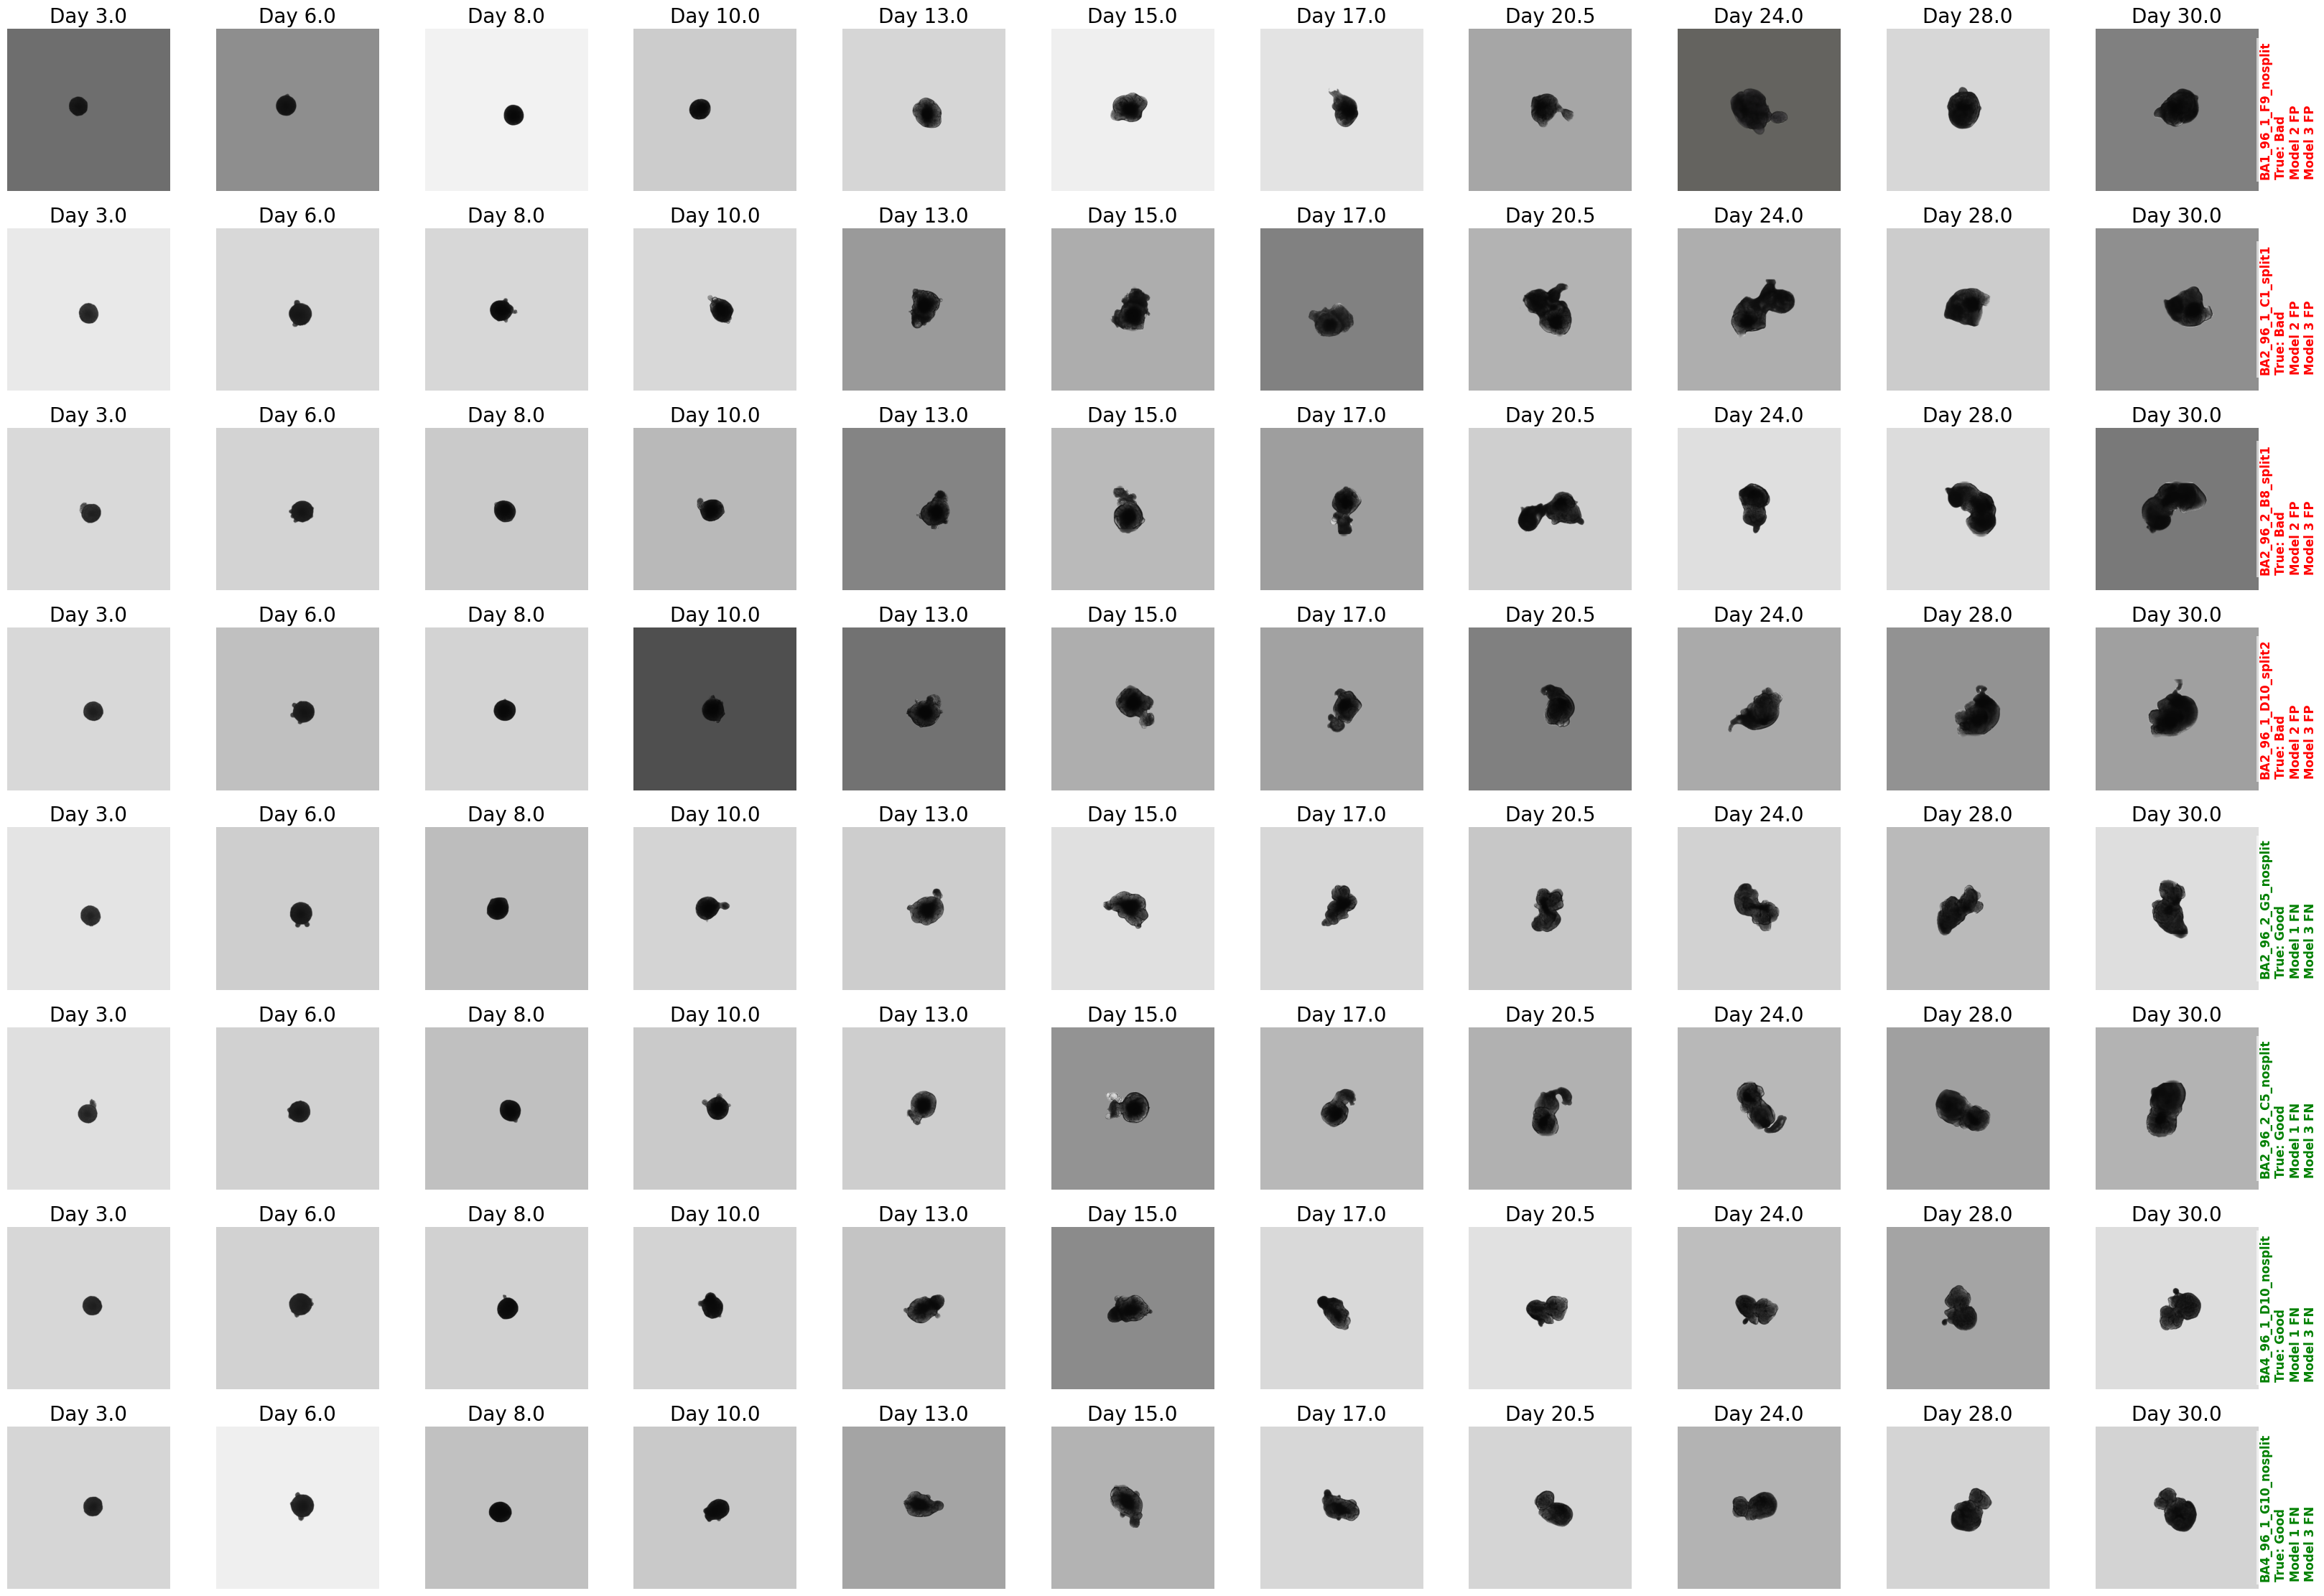

In [9]:
# ==== Time-series montages of problematic organoids (vertical side labels) ====
import numpy as np, cv2, json, sys
import matplotlib.pyplot as plt
from pathlib import Path
from skimage.io import imread

def add_repo_root(markers=("config.py", ".env")):
    here = Path.cwd()
    for p in [here, *here.parents]:
        if all((p / m).exists() for m in markers):
            sys.path.insert(0, str(p))
            return p
    raise RuntimeError("Could not find repo root with config.py and .env")

repo_root = add_repo_root()
from config import OUTPUT_FOLDER

BLUR_KERNEL = (5, 5)

ANNOTATIONS = {
    "BA1_96_1_F9_nosplit":  ("Bad",  ["Model 2 FP", "Model 3 FP"]),
    "BA2_96_1_C1_split1":   ("Bad",  ["Model 2 FP", "Model 3 FP"]),
    "BA2_96_2_B8_split1":   ("Bad",  ["Model 2 FP", "Model 3 FP"]),
    "BA2_96_1_D10_split2":  ("Bad",  ["Model 2 FP", "Model 3 FP"]),
    "BA2_96_2_G5_nosplit":  ("Good", ["Model 1 FN", "Model 3 FN"]),
    "BA2_96_2_C5_nosplit":  ("Good", ["Model 1 FN", "Model 3 FN"]),
    "BA4_96_1_D10_nosplit": ("Good", ["Model 1 FN", "Model 3 FN"]),
    "BA4_96_1_G10_nosplit": ("Good", ["Model 1 FN", "Model 3 FN"]),
}
PROBLEMATIC_IDS = list(ANNOTATIONS.keys())

def load_json(p):
    with open(p) as f:
        return json.load(f)

def to_rgb(img):
    return np.stack([img]*3, axis=-1) if img.ndim == 2 else img

def read_mask(mask_path, shape_hw):
    if mask_path and Path(mask_path).exists():
        m = imread(mask_path)
        if m.ndim == 3:
            m = m[:, :, 0]
        m = m.astype(np.float32) / 255.0
        if BLUR_KERNEL is not None:
            m = cv2.GaussianBlur(m, BLUR_KERNEL, 0)
        if m.shape != shape_hw:
            m = cv2.resize(m, (shape_hw[1], shape_hw[0]), interpolation=cv2.INTER_NEAREST)
        return m
    return np.zeros(shape_hw, dtype=np.float32)

def mean_fill(img, mask):
    mean_rgb = img.reshape(-1, 3).mean(axis=0)[None, None, :]
    out = img * mask[:, :, None] + mean_rgb * (1.0 - mask[:, :, None])
    return np.clip(out / 255.0, 0, 1)

# ---- load ----
series_metadata = load_json(OUTPUT_FOLDER / 'complete_series_metadata_no_blanks.json')
data = load_json(OUTPUT_FOLDER / 'complete_series_data_no_blanks.json')

problematic_ids = [oid for oid in PROBLEMATIC_IDS if oid in series_metadata]
if not problematic_ids:
    raise RuntimeError("No problematic organoids found in metadata!")

max_T = max(len(series_metadata[oid]['entry_keys']) for oid in problematic_ids)

# Slightly narrower height per row; extra right margin for vertical label
fig, axes = plt.subplots(
    len(problematic_ids), max_T,
    figsize=(3.0 * max_T, 2.8 * len(problematic_ids))
)
if len(problematic_ids) == 1:
    axes = np.expand_dims(axes, 0)
if max_T == 1:
    axes = np.expand_dims(axes, 1)

for r, oid in enumerate(problematic_ids):
    ek_list = series_metadata[oid]['entry_keys']
    days = series_metadata[oid]['days']
    true_label, model_notes = ANNOTATIONS[oid]
    note_text = f"{oid}\nTrue: {true_label}\n" + "\n".join(model_notes)

    for c in range(max_T):
        ax = axes[r, c]
        ax.axis('off')
        if c >= len(ek_list):
            continue
        ek = ek_list[c]
        entry = data[ek]

        img_path = entry['lstm_processed']['image_path']
        mask_path = entry['lstm_processed'].get('mask_path')

        img = to_rgb(imread(img_path)).astype(np.float32)
        mask = read_mask(mask_path, img.shape[:2])
        filled = mean_fill(img, mask)

        ax.imshow(filled)
        ax.set_title(f"Day {entry.get('mdl_day', days[c]):.1f}", fontsize=20)

    # put a vertical, rotated annotation on the far right of the row
    ax_last = axes[r, min(len(ek_list) - 1, max_T - 1)]
    ax_last.text(
        1.01, 0.5, note_text,
        transform=ax_last.transAxes,
        fontsize=12,
        va='center',
        ha='left',
        rotation=90,               # ← rotate vertical
        color=('green' if true_label == "Good" else 'red'),
        fontweight='bold',
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=3)
    )

plt.subplots_adjust(right=0.92, top=0.92)
#plt.suptitle("Problematic Organoid Time Series (vertical annotations)", fontsize=13, y=0.98)
plt.tight_layout()
plt.show()


✅ Loaded global mean RGB: [0.72615081 0.72603485 0.72570767]
   (In 0-255 scale: [185.2, 185.1, 185.1])


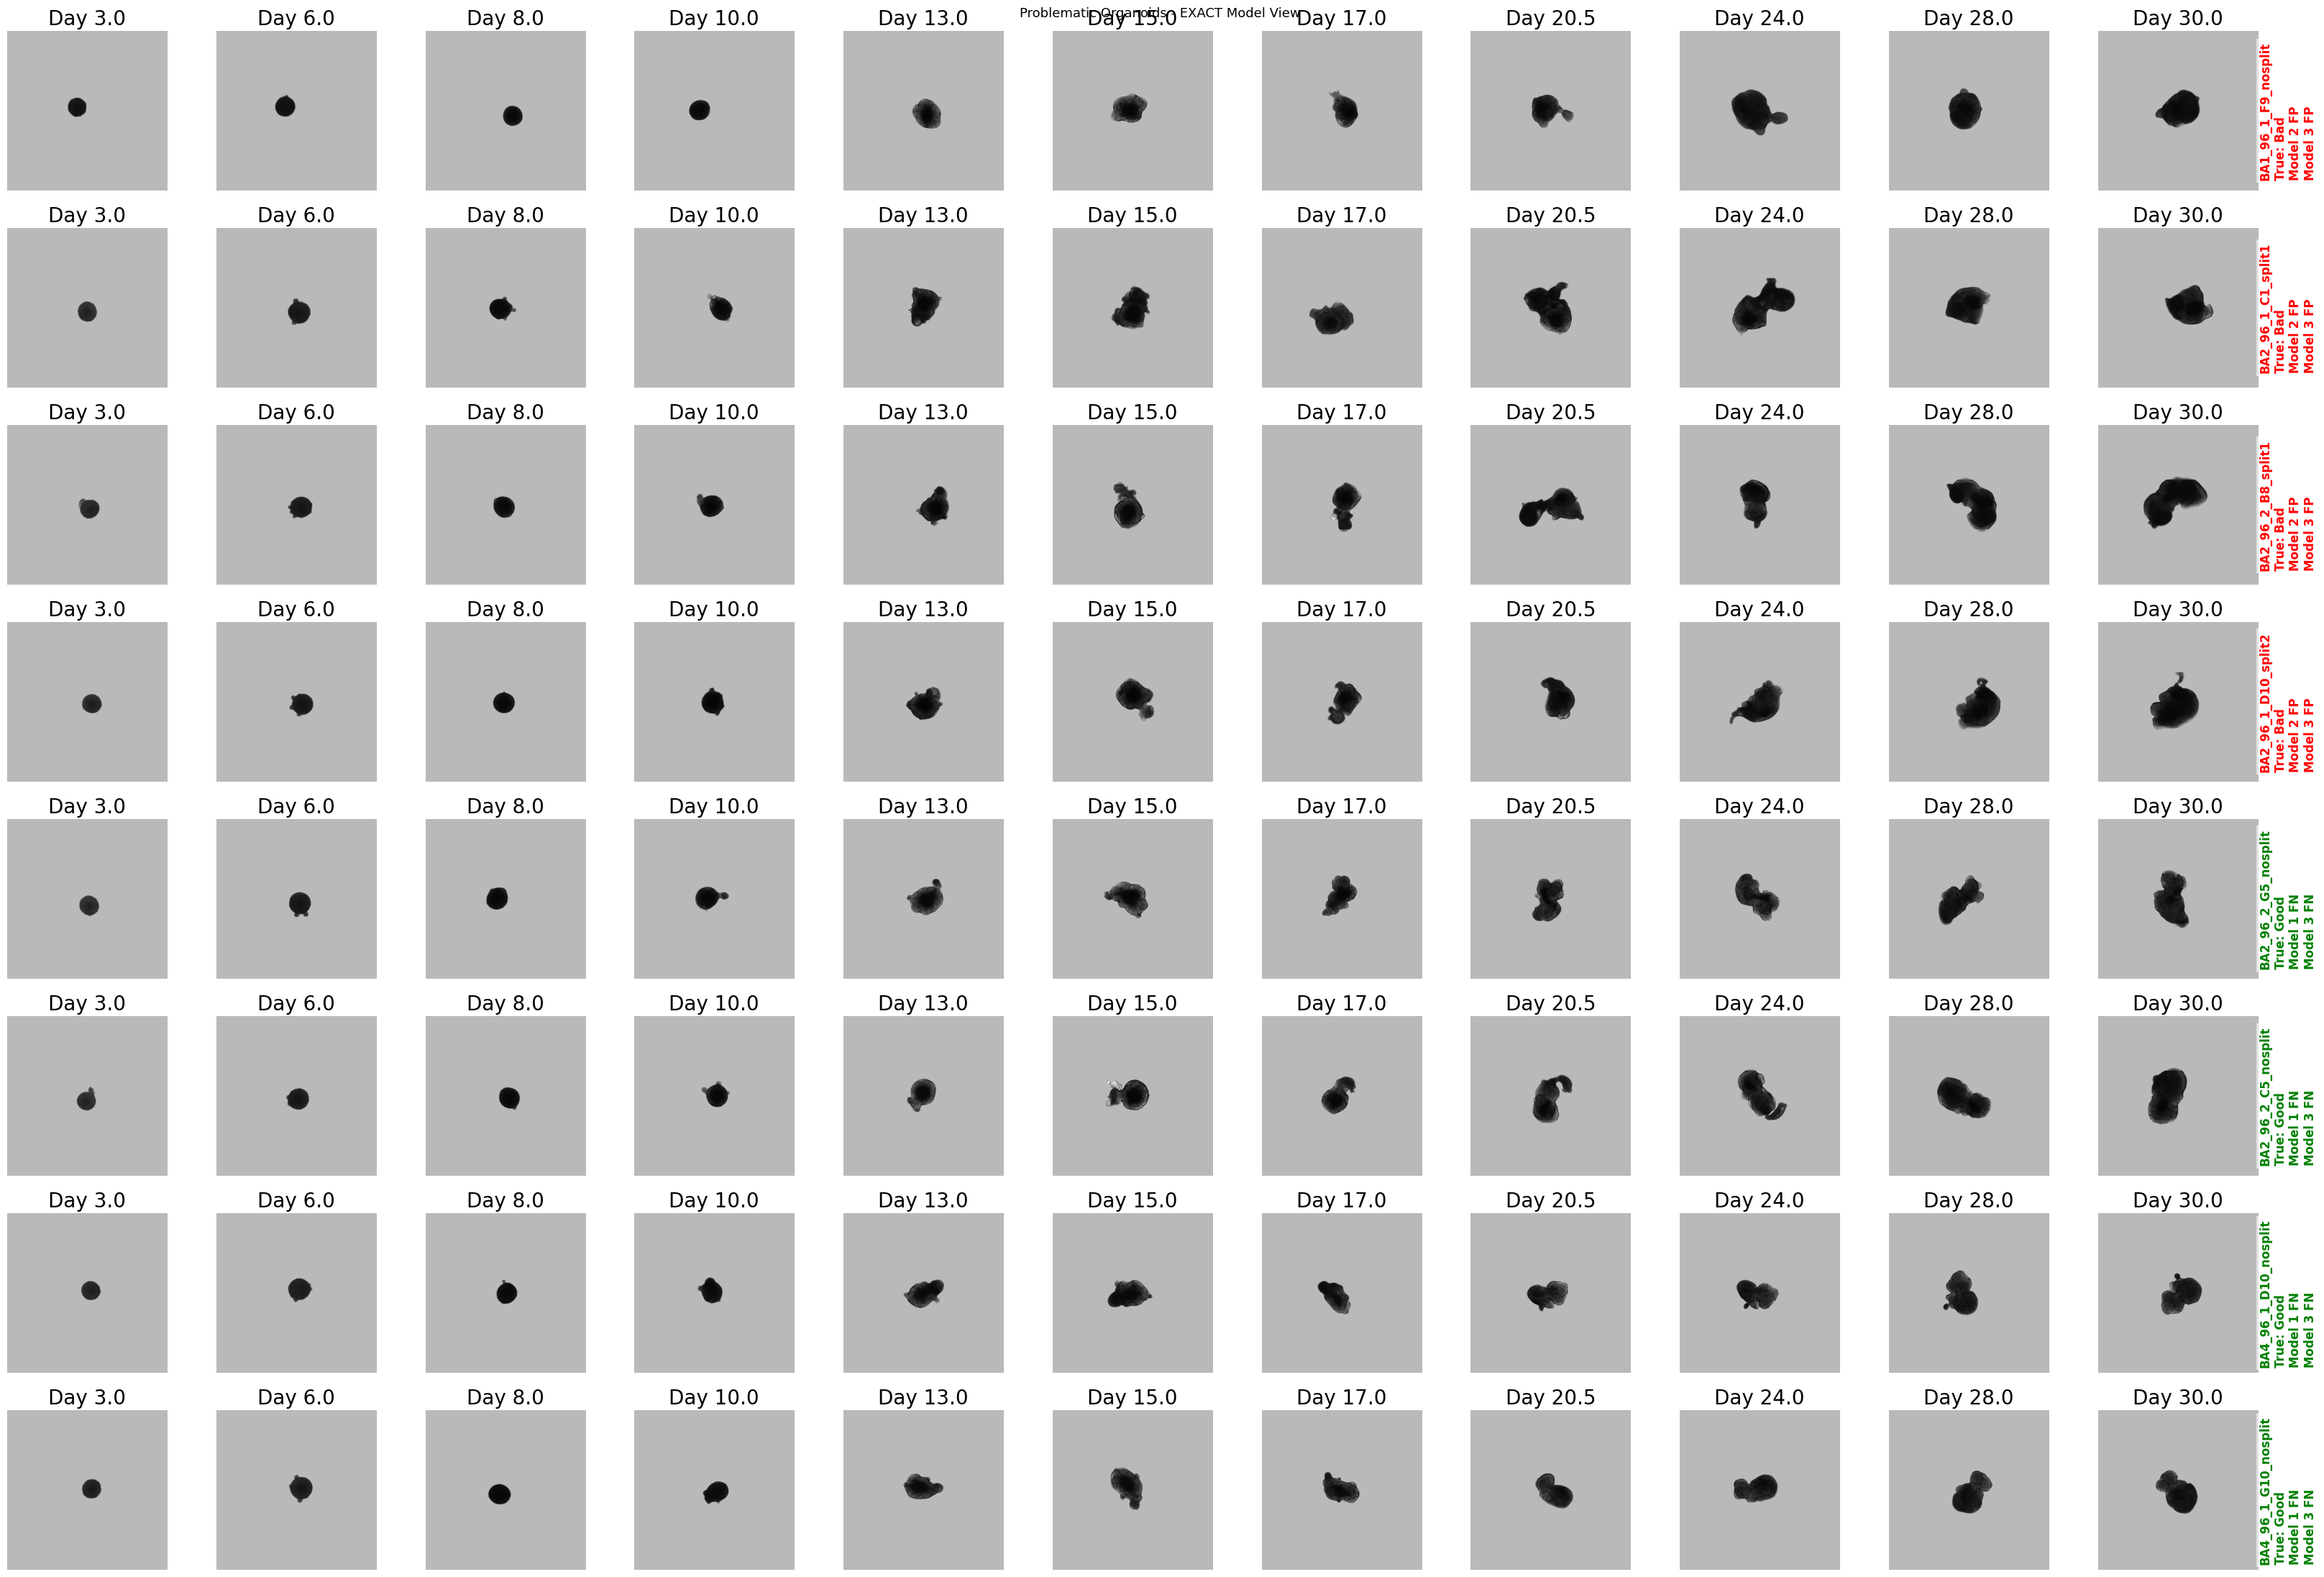

In [13]:
# ==== Time-series montages of problematic organoids (EXACT MODEL VIEW) ====
import numpy as np, cv2, json, sys
import matplotlib.pyplot as plt
from pathlib import Path
from skimage.io import imread

def add_repo_root(markers=("config.py", ".env")):
    here = Path.cwd()
    for p in [here, *here.parents]:
        if all((p / m).exists() for m in markers):
            sys.path.insert(0, str(p))
            return p
    raise RuntimeError("Could not find repo root with config.py and .env")

repo_root = add_repo_root()
from config import OUTPUT_FOLDER

# ---- MATCH TRAINING PARAMETERS ----
BLUR_KERNEL = (7, 7)  # ← Updated to match training!

ANNOTATIONS = {
    "BA1_96_1_F9_nosplit":  ("Bad",  ["Model 2 FP", "Model 3 FP"]),
    "BA2_96_1_C1_split1":   ("Bad",  ["Model 2 FP", "Model 3 FP"]),
    "BA2_96_2_B8_split1":   ("Bad",  ["Model 2 FP", "Model 3 FP"]),
    "BA2_96_1_D10_split2":  ("Bad",  ["Model 2 FP", "Model 3 FP"]),
    "BA2_96_2_G5_nosplit":  ("Good", ["Model 1 FN", "Model 3 FN"]),
    "BA2_96_2_C5_nosplit":  ("Good", ["Model 1 FN", "Model 3 FN"]),
    "BA4_96_1_D10_nosplit": ("Good", ["Model 1 FN", "Model 3 FN"]),
    "BA4_96_1_G10_nosplit": ("Good", ["Model 1 FN", "Model 3 FN"]),
}
PROBLEMATIC_IDS = list(ANNOTATIONS.keys())

def load_json(p):
    with open(p) as f:
        return json.load(f)

def to_rgb(img):
    return np.stack([img]*3, axis=-1) if img.ndim == 2 else img

def read_mask(mask_path, shape_hw):
    if mask_path and Path(mask_path).exists():
        m = imread(mask_path)
        if m.ndim == 3:
            m = m[:, :, 0]
        m = m.astype(np.float32) / 255.0
        if BLUR_KERNEL is not None:
            m = cv2.GaussianBlur(m, BLUR_KERNEL, 0)
        if m.shape != shape_hw:
            m = cv2.resize(m, (shape_hw[1], shape_hw[0]), interpolation=cv2.INTER_NEAREST)
        return m
    return np.zeros(shape_hw, dtype=np.float32)

def mean_fill(img, mask, global_mean):
    """Use GLOBAL mean (not per-image) - matches training!
    
    Args:
        img: Image in [0, 255] range (float32)
        mask: Mask in [0, 1] range
        global_mean: Global mean in [0, 1] range (as saved by training)
    
    Returns:
        Filled image in [0, 1] range
    """
    # Scale global_mean to match img's [0, 255] range
    mean_rgb = (global_mean * 255.0)[None, None, :]
    
    # Blend: foreground (img * mask) + background (mean * (1-mask))
    out = img * mask[:, :, None] + mean_rgb * (1.0 - mask[:, :, None])
    
    # Normalize to [0, 1]
    return np.clip(out / 255.0, 0, 1)

# ---- Load metadata ----
series_metadata = load_json(OUTPUT_FOLDER / 'complete_series_metadata_no_blanks.json')
data = load_json(OUTPUT_FOLDER / 'complete_series_data_no_blanks.json')

# ---- Load EXACT global mean from training ----
global_mean_path = OUTPUT_FOLDER / 'cnn_lstm' / 'global_mean.npy'

if not global_mean_path.exists():
    raise FileNotFoundError(
        f"❌ Global mean not found at {global_mean_path}\n"
        f"Please run training first to generate it!\n"
        f"It should be created when you run train_organoid_lstm.py"
    )

global_mean = np.load(global_mean_path)
print(f"✅ Loaded global mean RGB: {global_mean}")
print(f"   (In 0-255 scale: [{global_mean[0]*255:.1f}, {global_mean[1]*255:.1f}, {global_mean[2]*255:.1f}])")

# ---- Build montages ----
problematic_ids = [oid for oid in PROBLEMATIC_IDS if oid in series_metadata]
if not problematic_ids:
    raise RuntimeError("No problematic organoids found in metadata!")

max_T = max(len(series_metadata[oid]['entry_keys']) for oid in problematic_ids)

fig, axes = plt.subplots(
    len(problematic_ids), max_T,
    figsize=(3.0 * max_T, 2.8 * len(problematic_ids))
)
if len(problematic_ids) == 1:
    axes = np.expand_dims(axes, 0)
if max_T == 1:
    axes = np.expand_dims(axes, 1)

for r, oid in enumerate(problematic_ids):
    ek_list = series_metadata[oid]['entry_keys']
    days = series_metadata[oid]['days']
    true_label, model_notes = ANNOTATIONS[oid]
    note_text = f"{oid}\nTrue: {true_label}\n" + "\n".join(model_notes)

    for c in range(max_T):
        ax = axes[r, c]
        ax.axis('off')
        if c >= len(ek_list):
            continue
        ek = ek_list[c]
        entry = data[ek]

        img_path = entry['lstm_processed']['image_path']
        mask_path = entry['lstm_processed'].get('mask_path')

        img = to_rgb(imread(img_path)).astype(np.float32)
        mask = read_mask(mask_path, img.shape[:2])
        filled = mean_fill(img, mask, global_mean)  # ← Pass global_mean!

        ax.imshow(filled)
        ax.set_title(f"Day {entry.get('mdl_day', days[c]):.1f}", fontsize=20)

    # Vertical annotation on the far right
    ax_last = axes[r, min(len(ek_list) - 1, max_T - 1)]
    ax_last.text(
        1.01, 0.5, note_text,
        transform=ax_last.transAxes,
        fontsize=12,
        va='center',
        ha='left',
        rotation=90,
        color=('green' if true_label == "Good" else 'red'),
        fontweight='bold',
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=3)
    )

plt.subplots_adjust(right=0.92, top=0.92)
plt.suptitle("Problematic Organoids - EXACT Model View", fontsize=13, y=0.98)
plt.tight_layout()
plt.show()


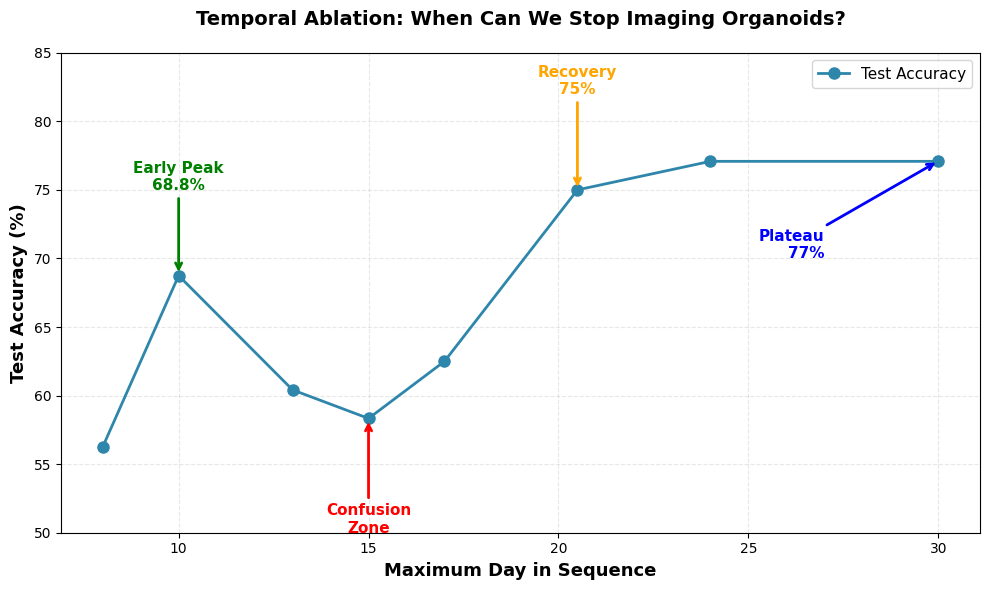

In [15]:
import json
import matplotlib.pyplot as plt
import numpy as np

# Load results
with open('/net/projects2/promega/data-analysis/output/cnn_lstm/temporal_ablation/temporal_ablation_results.json') as f:
    results = json.load(f)

days = [r['max_day'] for r in results]
test_acc = [r['test_acc'] * 100 for r in results]  # Convert to percentage
test_f1 = [r['test_f1'] * 100 for r in results]

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot with markers
ax.plot(days, test_acc, 'o-', linewidth=2, markersize=8, 
        label='Test Accuracy', color='#2E86AB')

# Annotate key points
ax.annotate('Early Peak\n68.8%', xy=(10, 68.8), xytext=(10, 75),
            arrowprops=dict(arrowstyle='->', color='green', lw=2),
            fontsize=11, ha='center', color='green', fontweight='bold')

ax.annotate('Confusion\nZone', xy=(15, 58.3), xytext=(15, 50),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=11, ha='center', color='red', fontweight='bold')

ax.annotate('Recovery\n75%', xy=(20.5, 75), xytext=(20.5, 82),
            arrowprops=dict(arrowstyle='->', color='orange', lw=2),
            fontsize=11, ha='center', color='orange', fontweight='bold')

ax.annotate('Plateau\n77%', xy=(30, 77.1), xytext=(27, 70),
            arrowprops=dict(arrowstyle='->', color='blue', lw=2),
            fontsize=11, ha='right', color='blue', fontweight='bold')

# Formatting
ax.set_xlabel('Maximum Day in Sequence', fontsize=13, fontweight='bold')
ax.set_ylabel('Test Accuracy (%)', fontsize=13, fontweight='bold')
ax.set_title('Temporal Ablation: When Can We Stop Imaging Organoids?', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim(50, 85)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

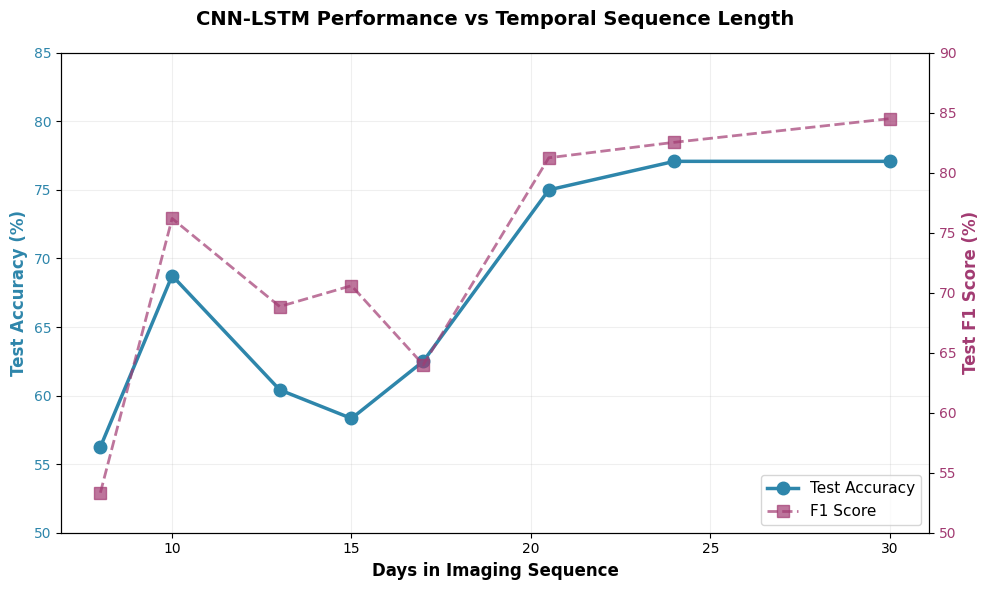

In [16]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Accuracy on left axis
color1 = '#2E86AB'
ax1.set_xlabel('Days in Imaging Sequence', fontsize=12, fontweight='bold')
ax1.set_ylabel('Test Accuracy (%)', fontsize=12, fontweight='bold', color=color1)
ax1.plot(days, test_acc, 'o-', linewidth=2.5, markersize=9, 
         label='Test Accuracy', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(50, 85)
ax1.grid(True, alpha=0.2)

# F1 score on right axis
ax2 = ax1.twinx()
color2 = '#A23B72'
ax2.set_ylabel('Test F1 Score (%)', fontsize=12, fontweight='bold', color=color2)
ax2.plot(days, test_f1, 's--', linewidth=2, markersize=8, 
         label='F1 Score', color=color2, alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(50, 90)

# Title and legend
plt.title('CNN-LSTM Performance vs Temporal Sequence Length', 
          fontsize=14, fontweight='bold', pad=20)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=11)

plt.tight_layout()

plt.show()

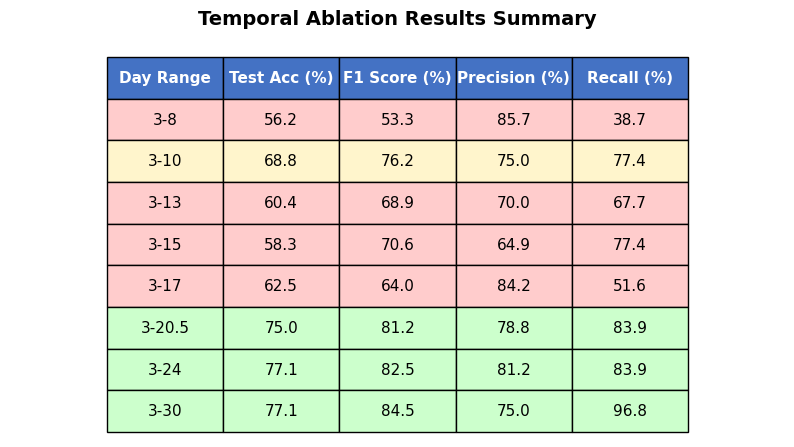

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Create summary dataframe
df = pd.DataFrame({
    'Day Range': [f'3-{int(d) if d == int(d) else d}' for d in days],
    'Test Acc (%)': [f'{acc:.1f}' for acc in test_acc],
    'F1 Score (%)': [f'{r["test_f1"]*100:.1f}' for r in results],
    'Precision (%)': [f'{r["test_precision"]*100:.1f}' for r in results],
    'Recall (%)': [f'{r["test_recall"]*100:.1f}' for r in results]
})

fig, ax = plt.subplots(figsize=(10, 5))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=df.values, colLabels=df.columns,
                cellLoc='center', loc='center',
                colWidths=[0.15, 0.15, 0.15, 0.15, 0.15])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Color code the rows
for i in range(len(df)):
    acc = test_acc[i]
    color = '#ffcccc' if acc < 65 else '#fff5cc' if acc < 72 else '#ccffcc'
    for j in range(len(df.columns)):
        table[(i+1, j)].set_facecolor(color)

# Header styling
for j in range(len(df.columns)):
    table[(0, j)].set_facecolor('#4472C4')
    table[(0, j)].set_text_props(weight='bold', color='white')

plt.title('Temporal Ablation Results Summary', fontsize=14, fontweight='bold', pad=20)

plt.show()

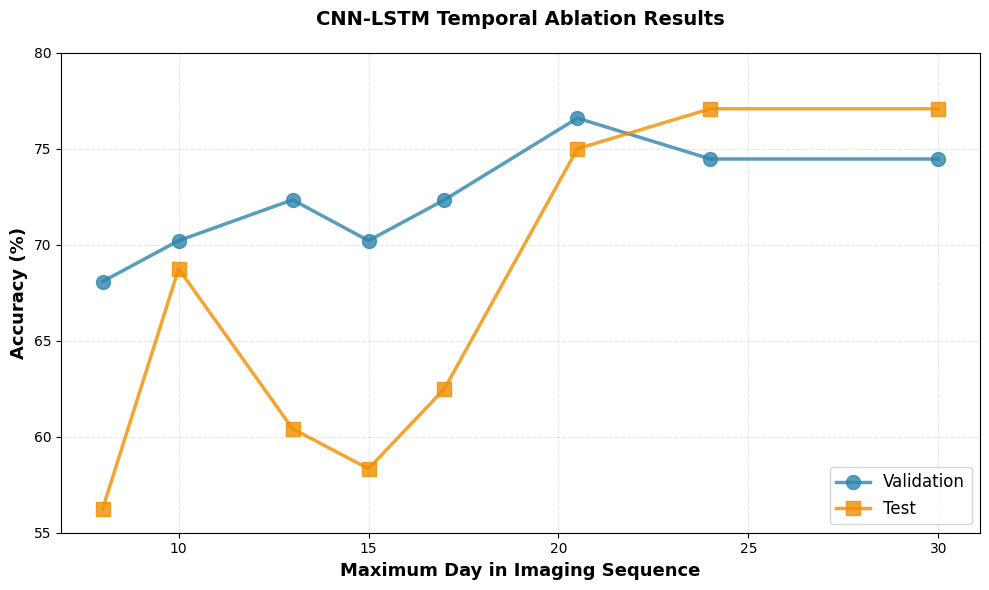

In [20]:
import json
import matplotlib.pyplot as plt
import numpy as np

days = [r['max_day'] for r in results]
val_acc = [r['best_val_acc'] * 100 for r in results]
test_acc = [r['test_acc'] * 100 for r in results]

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot both lines
ax.plot(days, val_acc, 'o-', linewidth=2.5, markersize=10, 
        label='Validation', color='#2E86AB', alpha=0.8)
ax.plot(days, test_acc, 's-', linewidth=2.5, markersize=10, 
        label='Test', color='#F18F01', alpha=0.8)

# Formatting
ax.set_xlabel('Maximum Day in Imaging Sequence', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=13, fontweight='bold')
ax.set_title('CNN-LSTM Temporal Ablation Results', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim(55, 80)
ax.legend(fontsize=12, loc='lower right')

plt.tight_layout()

plt.show()